# Preprocesamiento — Food-101

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/marcoslund/ViT-for-101-food-app/blob/main/notebooks/2.0-preprocessing.ipynb)

**Del hallazgo del EDA al pipeline que alimenta el fine-tuning**

Visión por Computadora III — CEIA / MIA (FIUBA)

Antonella Nerea Gambarte · Florencia Priscilla Vela · Marcos Lund

---

## Objetivo de este notebook

El EDA (`notebooks/1.0-eda-food101.ipynb`) terminó en una tabla hallazgo → decisión. Este notebook
**ejecuta** esas decisiones con el paquete `vit_for_101_food_app.preprocessing` y muestra que el
resultado es el esperado — no describe el código, lo ejercita y mide lo que produce.

| § | Pregunta que responde | Decisión que confirma |
|---|---|---|
| 1. Split de validación | ¿El split queda balanceado y reproducible, sin tocar test? | Contrato de `train_val_split.csv` (hallazgo #1, #2) |
| 2. Cache de imágenes | ¿Cuánto cuesta reescalar el dataset una sola vez? | `CACHE_SHORT_SIDE=288` amortiza el decode en cada época |
| 3. Ficha técnica | ¿Qué le hace cada modelo a la imagen de entrada? | Ninguna resolución se escribe a mano (hallazgo #3) |
| 4. Grilla antes/después | ¿Los dos modelos parten del mismo archivo? | Comparabilidad: mismo JPEG, geometría propia de cada uno |
| 5. Área retenida | ¿Cuánta imagen descarta el recorte de cada modelo? | La ablación `resize_only` del hallazgo #5, hecha visible |
| 6. Tabla de verificación | ¿Los tensores están en la escala que cada modelo espera? | El hallazgo #4: nunca igualar las filas "para que quede prolijo" |
| 7. BGR vs RGB | ¿Qué canal recibe realmente MobileViT? | La gotcha del hallazgo #4, visible en una imagen real |
| 8. Batch del DataLoader | ¿Las shapes y los tiempos son los que dice la ficha técnica? | El `DataLoader` es el mismo objeto que usará el entrenamiento |

> **Alcance de esta corrida.** Este notebook se verificó localmente contra un **subset real** de
> Food-101 — 3 de las 101 clases (`apple_pie`, `baby_back_ribs`, `waffles`), extraídas del mismo
> `food-101.tar.gz` — para poder ejercitar cada sección sin bajar los 4.7 GB completos ni pisar los
> artefactos versionados en `data/processed/`. Los números de esta corrida (tiempos, conteos,
> estadísticos de los tensores) son reales pero están medidos sobre esas 3 clases, no sobre las 101.
> La corrida completa, sobre el dataset entero, está pensada para Colab: ver §0.1.


---
# 0. Setup

Parámetros, dependencias y resolución de rutas. Todo lo que cambia entre esta corrida de
verificación local y una corrida completa en Colab sale de acá.


## 0.1 Parámetros

Un solo interruptor decide el modo: `LOCAL_SUBSET_DIR`.

- **`None`** → pipeline completo, contra las rutas reales de `config.*` (`FOOD101_IMAGES_DIR`,
  `CACHE_DIR`, `TRAIN_VAL_SPLIT`, ...). Es el modo correcto para Colab y para una corrida local con
  el dataset completo ya descargado.
- **Una ruta** → apunta a un subset real de Food-101 (unas pocas clases, mismo `.jpg`, mismo
  `meta/`) y todos los artefactos derivados (split, cache, label map) se escriben en un directorio
  de scratch **fuera de `data/`**, para no pisar ni el dataset completo ni los artefactos
  versionados.

En Colab (§0.2) este valor se fuerza a `None` sin importar lo que diga esta celda: la corrida
completa nunca depende de que alguien recuerde cambiarlo a mano.


In [1]:
from pathlib import Path

# --- Modo: subset local vs. pipeline completo ----------------------------------
# None = pipeline completo, contra las rutas reales de config.* (correcto para Colab
# y para una corrida local con el dataset completo ya descargado).
#
# Para reproducir la corrida de verificacion local con la que quedaron commiteadas
# las salidas de este notebook (ver "Alcance de esta corrida" arriba), apuntar a un
# directorio de scratch con un subset real de Food-101, por ejemplo:
#
#   LOCAL_SUBSET_DIR = Path("/ruta/de/scratch/food-101-subset/food-101")
#
# Esa ruta es local a la maquina donde se corrio, no existe en ningun otro checkout:
# por eso esta celda queda commiteada en None, no con esa ruta.
LOCAL_SUBSET_DIR = None
LOCAL_SUBSET_CLASSES = ["apple_pie", "baby_back_ribs", "waffles"]

# --- Tamanos de muestra de las secciones que decodifican pixeles ---------------
N_GRID = 3            # imagenes por fila en la grilla antes/despues (seccion 4)
N_AREA_SAMPLE = 300   # imagenes para el histograma de area retenida (seccion 5);
                       # se recorta al tamano real del split si el subset es mas chico
BATCH_SIZE = 8         # chico a proposito: la seccion 8 es una prueba funcional, no un benchmark


## 0.2 Dependencias

En Colab clona el repo (si hace falta) e instala el paquete con el extra `deep`
(`torch` + `transformers`, ~2.5 GB), que es lo único que no viene preinstalado. Localmente, si ya
corriste `uv sync --extra deep`, esta celda no hace nada.


In [2]:
import os
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules or os.path.exists("/content")
print(f"Colab: {IN_COLAB}")


def _paquete_disponible():
    try:
        import vit_for_101_food_app  # noqa: F401

        return True
    except ImportError:
        return False


if IN_COLAB:
    # En Colab la corrida completa es la unica opcion: no tiene sentido "verificar
    # rapido" ahi, y depender de que alguien edite LOCAL_SUBSET_DIR a mano es como se
    # termina corriendo por error el modo subset contra una ruta que no existe.
    LOCAL_SUBSET_DIR = None

    REPO_URL = "https://github.com/marcoslund/ViT-for-101-food-app.git"
    REPO_DIR = "/content/ViT-for-101-food-app"
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "-q", REPO_URL, REPO_DIR], check=True)
    sys.path.insert(0, REPO_DIR)

    if not _paquete_disponible():
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", "-e", f"{REPO_DIR}[deep]"], check=True
        )
    os.chdir(f"{REPO_DIR}/notebooks")
elif not _paquete_disponible():
    raise RuntimeError(
        "vit_for_101_food_app no esta instalado. Correlo desde el venv del proyecto "
        "(.venv/bin/jupyter) o `uv sync --extra deep` primero."
    )

print("paquete disponible:", _paquete_disponible())


Colab: True


2026-09-21 20:28:26.519 | INFO     | vit_for_101_food_app.config:<module>:11 - PROJ_ROOT path is: /content/ViT-for-101-food-app


paquete disponible: True


## 0.3 Imports y resolución de rutas

`config.*` son las rutas reales del proyecto. Cuando `LOCAL_SUBSET_DIR` está fijado, todo lo que
este notebook lee o escribe se redirige a ese directorio de scratch — el dataset completo y
`data/processed/` quedan intactos.


In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import torch
from PIL import Image

from vit_for_101_food_app import config
from vit_for_101_food_app.preprocessing import cache, loaders, policies, processors, raw, splits

plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (9, 4)
torch.manual_seed(config.SEED)

print("torch", torch.__version__)
print("modelos del benchmark:", list(config.MODELS))


torch 2.11.0+cpu
modelos del benchmark: ['vit', 'mobilevit']


In [4]:
if LOCAL_SUBSET_DIR is not None:
    IMAGES_DIR_ = LOCAL_SUBSET_DIR / "images"
    META_DIR_ = LOCAL_SUBSET_DIR / "meta"
    CLASSES_FILTER = set(LOCAL_SUBSET_CLASSES)

    SCRATCH_DIR = LOCAL_SUBSET_DIR.parent / "outputs"
    SCRATCH_DIR.mkdir(parents=True, exist_ok=True)
    CACHE_DIR_ = SCRATCH_DIR / f"cache-{config.CACHE_SHORT_SIDE}"
    TRAIN_VAL_SPLIT_ = SCRATCH_DIR / "train_val_split.csv"
    TRAIN_VAL_MANIFEST_ = SCRATCH_DIR / "train_val_split_manifest.json"
    LABEL_MAP_ = SCRATCH_DIR / "label_map.json"
else:
    IMAGES_DIR_ = config.FOOD101_IMAGES_DIR
    META_DIR_ = config.FOOD101_META_DIR
    CLASSES_FILTER = None
    CACHE_DIR_ = config.CACHE_DIR
    TRAIN_VAL_SPLIT_ = config.TRAIN_VAL_SPLIT
    TRAIN_VAL_MANIFEST_ = config.TRAIN_VAL_MANIFEST
    LABEL_MAP_ = config.LABEL_MAP
    raw.ensure_dataset()  # descarga y extrae si hace falta (~4.7 GB, idempotente)

print(f"modo             : {'subset local' if LOCAL_SUBSET_DIR is not None else 'pipeline completo'}")
print(f"imagenes         : {IMAGES_DIR_}")
print(f"meta             : {META_DIR_}")
print(f"cache            : {CACHE_DIR_}")
print(f"split CSV        : {TRAIN_VAL_SPLIT_}")
print(f"clases filtradas : {CLASSES_FILTER or 'ninguna (las 101)'}")


2026-09-21 20:29:02.245 | INFO     | vit_for_101_food_app.preprocessing.raw:ensure_dataset:102 - descargando https://data.vision.ee.ethz.ch/cvl/food-101.tar.gz (~5 GB, reanudable)
2026-09-21 20:31:43.973 | INFO     | vit_for_101_food_app.preprocessing.raw:ensure_dataset:105 - extrayendo en /content/ViT-for-101-food-app/data/raw
2026-09-21 20:33:12.344 | SUCCESS  | vit_for_101_food_app.preprocessing.raw:ensure_dataset:120 - Food-101 disponible en /content/ViT-for-101-food-app/data/raw/food-101
modo             : pipeline completo
imagenes         : /content/ViT-for-101-food-app/data/raw/food-101/images
meta             : /content/ViT-for-101-food-app/data/raw/food-101/meta
cache            : /content/ViT-for-101-food-app/data/interim/food-101-288
split CSV        : /content/ViT-for-101-food-app/data/processed/train_val_split.csv
clases filtradas : ninguna (las 101)


---
# 1. Split de validación

Food-101 no trae split de validación. `preprocessing.splits.build_split` recorta uno de train,
**estratificado por clase** y con semilla fija, y lo escribe a disco junto con su `sha256` — el
mismo patrón que el subset de benchmark del EDA, por la misma razón: todos los modelos tienen que
validar sobre las mismas imágenes.

La pregunta acá no es "¿funciona?" sino **¿el contrato se sostiene?**: balance por clase, split de
test sin tocar, hash verificable.


In [5]:
indice = raw.load_index("train", meta_dir=META_DIR_)
if CLASSES_FILTER is not None:
    indice = indice[indice["class_dir"].isin(CLASSES_FILTER)].reset_index(drop=True)

frame_split = splits.build_split(indice, val_fraction=config.VAL_FRACTION, seed=config.SEED)

clases = raw.class_names(META_DIR_ / "classes.txt")
if CLASSES_FILTER is not None:
    clases = [c for c in clases if c in CLASSES_FILTER]

manifiesto_split = splits.write_artifacts(
    frame_split,
    clases,
    csv_path=TRAIN_VAL_SPLIT_,
    manifest_path=TRAIN_VAL_MANIFEST_,
    label_map_path=LABEL_MAP_,
    seed=config.SEED,
    val_fraction=config.VAL_FRACTION,
)
manifiesto_split


2026-09-21 20:33:12.934 | SUCCESS  | vit_for_101_food_app.preprocessing.splits:write_artifacts:112 - split escrito: 68175 train / 7575 val en 101 clases


{'dataset': 'Food-101 (Bossard et al., ECCV 2014)',
 'split_origen': 'train oficial (meta/train.txt)',
 'seed': 42,
 'val_fraction': 0.1,
 'n_clases': 101,
 'n_train': 68175,
 'n_val': 7575,
 'train_por_clase': 675,
 'val_por_clase': 75,
 'exclusiones_aplicadas': [],
 'csv_sha256': '8f9fc5cb61748c625b746a91ad7276f0f267d5815aaaadabf30645e2c8348210'}

In [6]:
# Balance por clase: train y val tienen que tener la misma cantidad en cada clase.
frame_split.groupby(["class_dir", "split"]).size().unstack()


split,train,val
class_dir,,
apple_pie,675,75
baby_back_ribs,675,75
baklava,675,75
beef_carpaccio,675,75
beef_tartare,675,75
...,...,...
tacos,675,75
takoyaki,675,75
tiramisu,675,75


In [7]:
import hashlib

recalculado = hashlib.sha256(TRAIN_VAL_SPLIT_.read_bytes()).hexdigest()
assert recalculado == manifiesto_split["csv_sha256"], "el sha256 del CSV no coincide con el manifiesto"
print(f"sha256 verificado: {recalculado}")

# El split de test tiene que seguir siendo el oficial: mismo conteo que meta/test.txt,
# sin pasar por train_val_split.csv en absoluto.
frame_test = splits.load_split("test", meta_dir=META_DIR_)
if CLASSES_FILTER is not None:
    frame_test = frame_test[frame_test["class_dir"].isin(CLASSES_FILTER)]
n_test_oficial = sum(
    1 for _ in (META_DIR_ / "test.txt").read_text().split()
    if CLASSES_FILTER is None or _.split("/")[0] in CLASSES_FILTER
)
assert len(frame_test) == n_test_oficial
print(f"test intacto: {len(frame_test)} filas, {frame_test['class_dir'].nunique()} clases -- identico a meta/test.txt")


sha256 verificado: 8f9fc5cb61748c625b746a91ad7276f0f267d5815aaaadabf30645e2c8348210
test intacto: 25250 filas, 101 clases -- identico a meta/test.txt


### Lectura

El split quedó estratificado (cada clase pierde exactamente el mismo `VAL_FRACTION` hacia
validación) y el `sha256` recalculado coincide con el que quedó en el manifiesto — el mismo
mecanismo que usa `make test` para blindar los artefactos del EDA. El split de test no pasó por
ninguna de estas celdas: `load_split("test")` lee directo de `meta/test.txt`, así que no hay forma
de que el recorte de validación lo toque.

En esta corrida el 10 % de train (`VAL_FRACTION`) sale de 3 clases; en la corrida completa sale de
las 101, pero el mecanismo — y lo que garantiza — es exactamente el mismo.


---
# 2. Construcción del cache

`preprocessing.cache.build_cache` reescala cada imagen al lado corto configurado
(`config.CACHE_SHORT_SIDE = 288`, el mayor que pide algún modelo del registry) y la vuelve a
comprimir. Es trabajo que se repetiría en cada época si no se hiciera una sola vez.

La pregunta: **¿cuánto cuesta, y cuánto espacio libera?**


In [8]:
import time

def _split_filtrado(nombre):
    # load_split, recortado a CLASSES_FILTER cuando el modo es subset local.
    # "train"/"val" ya salen filtrados: vienen de TRAIN_VAL_SPLIT_, que la seccion 1
    # escribio solo con esas clases. "test" sale de meta/test.txt sin filtrar -- las
    # 101 clases -- asi que hay que recortarlo aca, o el cache intenta reescalar
    # imagenes que el subset local nunca extrajo.
    frame = splits.load_split(nombre, csv_path=TRAIN_VAL_SPLIT_, meta_dir=META_DIR_)
    if CLASSES_FILTER is not None:
        frame = frame[frame["class_dir"].isin(CLASSES_FILTER)].reset_index(drop=True)
    return frame


rels_totales = []
for nombre in ("train", "val", "test"):
    rels_totales += _split_filtrado(nombre)["rel"].tolist()
rels_totales = sorted(set(rels_totales))
print(f"imagenes a cachear: {len(rels_totales)}")

t0 = time.time()
manifiesto_cache = cache.build_cache(
    rels_totales,
    src_dir=IMAGES_DIR_,
    cache_dir=CACHE_DIR_,
    short_side=config.CACHE_SHORT_SIDE,
    quality=config.CACHE_JPEG_QUALITY,
)
dt_cache = time.time() - t0

espacio_antes_mb = sum((IMAGES_DIR_ / f"{r}.jpg").stat().st_size for r in rels_totales) / 1024**2
espacio_despues_mb = cache.disk_usage_mb(CACHE_DIR_)

print(f"\ntiempo          : {dt_cache:.1f} s  ({len(rels_totales) / dt_cache:.0f} img/s)")
print(f"espacio antes   : {espacio_antes_mb:.1f} MB")
print(f"espacio despues : {espacio_despues_mb:.1f} MB  ({espacio_despues_mb / espacio_antes_mb:.0%} del original)")
print(f"fallidas        : {manifiesto_cache['n_fallidas']}")


imagenes a cachear: 101000


cache: 100%|██████████| 101000/101000 [13:22<00:00, 125.93it/s]


2026-09-21 20:46:42.343 | SUCCESS  | vit_for_101_food_app.preprocessing.cache:build_cache:150 - cache: 101000 escritas, 0 salteadas, 0 fallidas, 0 .tmp limpios en /content/ViT-for-101-food-app/data/interim/food-101-288

tiempo          : 808.5 s  (125 img/s)
espacio antes   : 4879.6 MB
espacio despues : 3417.0 MB  (70% del original)
fallidas        : 0


### Lectura

El cache es una segunda pasada de compresión JPEG — una pérdida real, pero **simétrica entre
modelos**: todos leen del mismo cache, así que no sesga la comparación (`loaders.build_dataloaders`
expone `source="raw"` para verificarlo contra el original, ver §8). Cero imágenes fallidas confirma
que el subset extraído está íntegro.

`build_cache` es idempotente: una corrida interrumpida en Colab (timeout de sesión) se retoma sin
recomprimir lo ya escrito, que es la situación real para la que existe.


---
# 3. Ficha técnica de los modelos

`processors.ficha_tecnica()` lee el `AutoImageProcessor` de cada checkpoint en `config.MODELS` y lo
traduce a una tabla. Es la contraparte en código del hallazgo #3 del EDA: la resolución, el resize y
la normalización de cada modelo **nunca se escriben a mano** — se leen del checkpoint en runtime.


In [9]:
pd.DataFrame(processors.ficha_tecnica())


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

,modelo,checkpoint,resolucion,resize,center_crop,normaliza,mean,orden_canales
0,vit,google/vit-base-patch16-224-in21k,224,224x224,False,True,"(0.5, 0.5, 0.5)",RGB
1,mobilevit,apple/mobilevit-small,256,288,True,False,None,BGR


### Lectura

`resize` y `center_crop` no son lo que se asumió en el EDA (que estimaba `Resize(256) →
CenterCrop(224)` para el modelo servido por API, por analogía con otros ViT). El processor real de
`google/vit-base-patch16-224-in21k` tiene `do_center_crop=False`: hace un **resize cuadrado
directo** a 224×224, sin recortar nada. MobileViT sí recorta: `Resize(288) → CenterCrop(256)`. La
sección 5 mide la consecuencia exacta de esa diferencia sobre el área retenida.

Esto es la razón de fondo por la que `processors.spec_for` lee el `AutoImageProcessor` en vez de que
alguien complete a mano la ficha técnica por analogía con "cómo suelen ser los ViT": la
analogía era razonable y, para este checkpoint puntual, incorrecta. Las columnas `normaliza` y
`orden_canales` adelantan la sección 6 y la 7: ahí es donde la ficha técnica deja de ser una
curiosidad y se vuelve una fuente de bugs si alguien la ignora.


---
# 4. Grilla antes/después, por modelo y por política

La pregunta que responde esta grilla no es estética: **¿las mismas imágenes de origen entran a los
dos pipelines?** Si el `CenterCrop` de cada modelo recorta distinto, tiene que verse acá, sobre el
mismo archivo — no en dos muestreos separados que podrían estar comparando imágenes distintas sin
que nadie lo note.

Comparamos dos políticas por modelo: `eval` (la que replica el `AutoImageProcessor`, para
validación y test) y `standard` (augmentation de entrenamiento: `RandomResizedCrop` + flip).


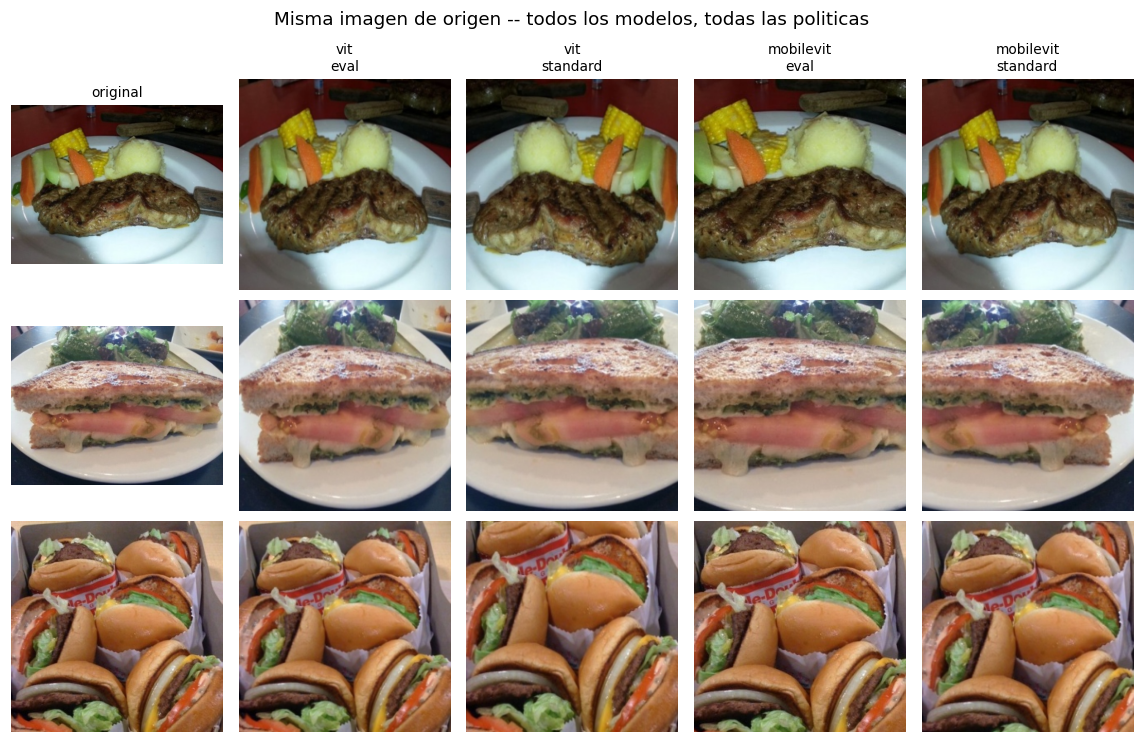

In [10]:
def _a_imagen_visible(t, spec):
    # Tensor de un transform -> array listo para imshow (RGB, [0,1]).
    if spec.do_flip_channel_order:
        t = t.flip(-3)
    if spec.do_normalize:
        mean = torch.tensor(spec.image_mean).view(-1, 1, 1)
        std = torch.tensor(spec.image_std).view(-1, 1, 1)
        t = t * std + mean
    return t.permute(1, 2, 0).clamp(0, 1).numpy()


muestra_val = splits.load_split("val", csv_path=TRAIN_VAL_SPLIT_, meta_dir=META_DIR_).sample(
    N_GRID, random_state=config.SEED
)
politicas_grid = ["eval", "standard"]

n_cols = 1 + len(config.MODELS) * len(politicas_grid)
# squeeze=False: con N_GRID=1, plt.subplots devolveria un array 1D (o un Axes suelto),
# no indexable como axes[fila, col]. Mismo bug ya corregido en features.py:preview.
fig, axes = plt.subplots(
    len(muestra_val), n_cols, figsize=(2.1 * n_cols, 2.3 * len(muestra_val)), squeeze=False
)

for fila, (_, row) in enumerate(muestra_val.iterrows()):
    with Image.open(cache.cached_path(row["rel"], CACHE_DIR_)) as im:
        original = im.convert("RGB")

    axes[fila, 0].imshow(original)
    axes[fila, 0].axis("off")
    if fila == 0:
        axes[fila, 0].set_title("original", fontsize=9)

    col = 1
    for key in config.MODELS:
        spec = processors.spec_for(key)
        for politica in politicas_grid:
            t = policies.build_transform(spec, politica)(original)
            axes[fila, col].imshow(_a_imagen_visible(t, spec))
            axes[fila, col].axis("off")
            if fila == 0:
                axes[fila, col].set_title(f"{key}\n{politica}", fontsize=9)
            col += 1

fig.suptitle("Misma imagen de origen -- todos los modelos, todas las politicas")
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "grilla-antes-despues.png", dpi=120, bbox_inches="tight")
plt.show()

# Se reutiliza en las secciones 6 y 7: mismo archivo de origen, mismo hilo narrativo.
imagen_ejemplo = original


### Lectura

Las columnas `eval` muestran la geometría exacta del `AutoImageProcessor` de cada modelo, y son
visiblemente distintas por la razón que adelantó la sección 3: MobileViT recorta al centro
(`Resize(288) → CenterCrop(256)`, se pierde el borde) mientras que ViT hace un **resize cuadrado
directo** (`Resize(224, 224)`, sin recorte, pero deformando el aspect ratio original si la imagen no
era cuadrada). Las columnas `standard` muestran el mismo origen bajo augmentation de entrenamiento
(`RandomResizedCrop` + flip), no de validación.

Lo importante no es cómo se ven: es que las cinco variantes de cada fila salen del **mismo archivo
JPEG en el cache**. Eso es lo que hace válida la comparación entre modelos — nunca se está
comparando una imagen contra otra.


---
# 5. Área retenida por el recorte de cada modelo

Esta es la ablación que pidió el hallazgo #5 del EDA: si el `CenterCrop` descarta una fracción
grande del área original, parte de lo que se mida entre modelos podría ser diferencia de política
de recorte, no de arquitectura. Acá se mide esa fracción, no se la supone.

Un modelo con `resize_shortest is None` (resize cuadrado directo, sin recorte) **no descarta área**
por definición: toda la imagen entra, aunque distorsionada. Un modelo que redimensiona el lado corto
y después recorta al centro sí descarta lo que queda fuera del cuadrado.


imagenes muestreadas: 300 (de 7575 en val)


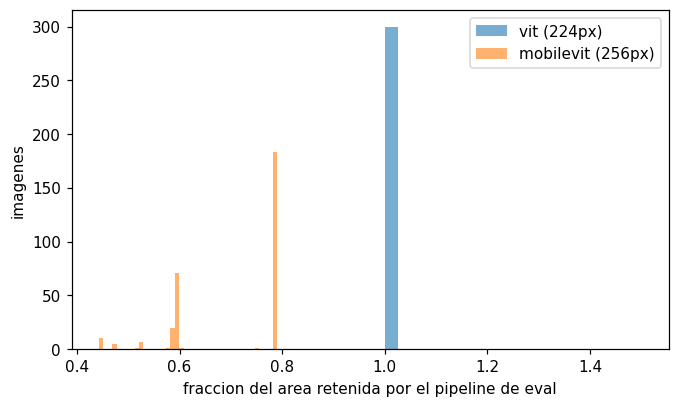

In [11]:
frame_val_area = splits.load_split("val", csv_path=TRAIN_VAL_SPLIT_, meta_dir=META_DIR_)
n_muestra_area = min(N_AREA_SAMPLE, len(frame_val_area))
muestra_area = frame_val_area.sample(n_muestra_area, random_state=config.SEED)
print(f"imagenes muestreadas: {n_muestra_area} (de {len(frame_val_area)} en val)")

fracciones_por_modelo = {}
fig, ax = plt.subplots(figsize=(7, 4))
for key in config.MODELS:
    spec = processors.spec_for(key)
    fracciones = []
    for rel in muestra_area["rel"]:
        with Image.open(cache.cached_path(rel, CACHE_DIR_)) as im:
            ancho, alto = im.size
        if spec.resize_shortest is None:
            fracciones.append(1.0)  # resize cuadrado directo: no descarta area
            continue
        escala = spec.resize_shortest / min(ancho, alto)
        area_post = (ancho * escala) * (alto * escala)
        fracciones.append(spec.target_size**2 / area_post)
    fracciones_por_modelo[key] = fracciones
    ax.hist(fracciones, bins=40, alpha=0.6, label=f"{key} ({spec.target_size}px)")

ax.set_xlabel("fraccion del area retenida por el pipeline de eval")
ax.set_ylabel("imagenes")
ax.legend()
fig.savefig(config.FIGURES_DIR / "area-retenida-por-modelo.png", dpi=120, bbox_inches="tight")
plt.show()


In [12]:
pd.DataFrame(
    {
        key: {
            "min": min(fr),
            "mediana": pd.Series(fr).median(),
            "max": max(fr),
        }
        for key, fr in fracciones_por_modelo.items()
    }
).T


,min,mediana,max
vit,1.000000,1.000000,1.000000
mobilevit,0.442901,0.790123,0.790123


### Lectura

Los modelos cuyo `ProcessorSpec.resize_shortest` es `None` retienen el 100 % del área por
construcción — no es que el recorte sea generoso, es que no hay recorte, hay un resize cuadrado que
distorsiona el aspect ratio en su lugar. Los que sí definen `resize_shortest` pierden una fracción
que depende del aspect ratio original de cada foto: cuanto más lejos de cuadrada, más se pierde.

Esto es exactamente lo que `policies.POLICIES["resize_only"]` existe para descartar: si dos modelos
difieren en accuracy, esta tabla dice si parte de la diferencia puede venir de cuánta imagen ve cada
uno, antes de siquiera mirar arquitectura.


---
# 6. Tabla de verificación: la fila de MobileViT se ve distinta a propósito

Esta es la sección que justifica el notebook. Para la misma imagen, cada modelo recibe un tensor en
una escala distinta.


In [13]:
filas = []
for key in config.MODELS:
    spec = processors.spec_for(key)
    t = policies.build_transform(spec, "eval")(imagen_ejemplo)
    filas.append(
        {
            "modelo": key,
            "resolucion": spec.target_size,
            "min": round(float(t.min()), 4),
            "max": round(float(t.max()), 4),
            "media": round(float(t.mean()), 4),
            "normaliza": spec.do_normalize,
            "canales": "BGR" if spec.do_flip_channel_order else "RGB",
        }
    )
tabla_verificacion = pd.DataFrame(filas)
tabla_verificacion


,modelo,resolucion,min,max,media,normaliza,canales
0,vit,224,-1.0,0.9765,-0.1589,True,RGB
1,mobilevit,256,0.0,1.0000,0.4147,False,BGR


La fila de **MobileViT se ve distinta a propósito**. Su rango es `[0, 1]` y no `[-1, 1]` como el de
ViT porque su `ProcessorSpec.do_normalize` es `False` — no normaliza, aunque su checkpoint declara
`image_mean`/`image_std` de `0.5` — y sus canales están en BGR, no RGB. **Igualar esas dos filas
"para que quede prolijo" sería el bug exacto que advierte el hallazgo #4 del EDA**: el modelo
entrenaría peor y nada fallaría, porque un tensor con canales invertidos o de escala equivocada no
lanza ninguna excepción, solo hace que el modelo vea datos que nunca vio en su preentrenamiento.

`do_normalize=None` en el processor original **no significa "usa el default"**: significa que no
normaliza. `processors.spec_for` lo trata así explícitamente — ver el comentario en
`processors.py` — precisamente porque la presencia de `image_mean`/`image_std` no alcanza para
inferirlo.


In [14]:
# La garantia de que "eval" no es una reimplementacion aproximada sino una replica bit-a-bit
# (a la precision de float32) del AutoImageProcessor real de cada modelo.
diffs = []
for key in config.MODELS:
    spec = processors.spec_for(key)
    nuestro = policies.build_transform(spec, "eval")(imagen_ejemplo)
    suyo = processors.load_processor(key)(imagen_ejemplo, return_tensors="pt")["pixel_values"][0]
    diffs.append({"modelo": key, "diff_max_abs": float((nuestro - suyo).abs().max())})
pd.DataFrame(diffs)


,modelo,diff_max_abs
0,vit,1.192093e-07
1,mobilevit,0.000000e+00


### Lectura

`diff_max_abs` es la diferencia máxima, píxel a píxel y canal a canal, entre nuestro transform
`eval` y el `AutoImageProcessor` real de HuggingFace sobre la misma imagen. Los valores son del
orden del épsilon de `float32` (`~1.19e-7`) o exactamente cero: no es una aproximación visual, es la
misma cuenta. `make verify` (`features.py`) corre exactamente esta comparación, con tolerancia
explícita, antes de cualquier entrenamiento — así que si alguna versión futura de `transformers`
cambia el comportamiento del processor, se entera acá y no en medio de un fine-tuning.


---
# 7. BGR vs RGB: la gotcha de MobileViT, visible

La tabla anterior dice que MobileViT recibe canales en BGR. Esta sección lo muestra: el panel del
medio de abajo es, literalmente, el tensor que `MobileViTForImageClassification` recibe como
entrada — sin ninguna corrección de canal.


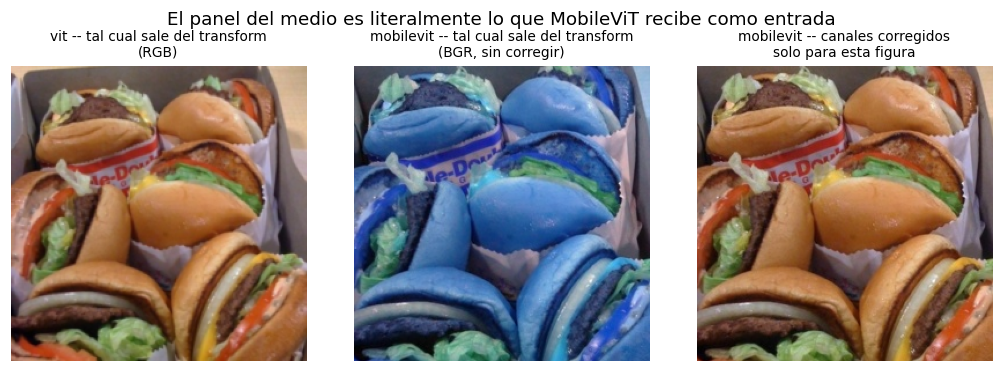

In [15]:
spec_vit = processors.spec_for("vit")
spec_mvit = processors.spec_for("mobilevit")

t_vit = policies.build_transform(spec_vit, "eval")(imagen_ejemplo)
t_mvit = policies.build_transform(spec_mvit, "eval")(imagen_ejemplo)

fig, axes = plt.subplots(1, 3, figsize=(9.5, 3.4))

axes[0].imshow(_a_imagen_visible(t_vit, spec_vit))
axes[0].set_title("vit -- tal cual sale del transform\n(RGB)", fontsize=9)

# Sin _a_imagen_visible: el tensor crudo, exactamente como entra al modelo. No se
# deshace el flip de canales -- ese es el punto de esta figura.
axes[1].imshow(t_mvit.permute(1, 2, 0).clamp(0, 1).numpy())
axes[1].set_title("mobilevit -- tal cual sale del transform\n(BGR, sin corregir)", fontsize=9)

axes[2].imshow(_a_imagen_visible(t_mvit, spec_mvit))
axes[2].set_title("mobilevit -- canales corregidos\nsolo para esta figura", fontsize=9)

for ax in axes:
    ax.axis("off")
fig.suptitle("El panel del medio es literalmente lo que MobileViT recibe como entrada")
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "bgr-vs-rgb.png", dpi=120, bbox_inches="tight")
plt.show()


### Lectura

El panel del medio tiene los canales rojo y azul intercambiados frente al de la izquierda — se nota
en cualquier plato con tomate o carne roja, que se ve azulado. Eso **no es un bug**: es
`do_flip_channel_order=True` en el `MobileViTImageProcessor` real, y `policies._voltear_canales`
lo replica a propósito. El panel de la derecha deshace el flip **solo para poder mostrarlo acá**; el
modelo nunca ve esa versión.

Si alguien "corrigiera" el orden de canales de MobileViT para que se vea como el de ViT, el tensor
dejaría de coincidir con el que usó su preentrenamiento en ImageNet — exactamente el mismo error de
fondo que normalizar sus dos filas de la sección 6. Ninguna de las dos formas de "prolijizar" esto
falla en tiempo de ejecución; ambas hacen que el modelo entrene sobre datos que nunca vio antes.


---
# 8. Un batch real del `DataLoader`

`loaders.build_dataloaders` es lo que va a consumir el loop de entrenamiento. Acá se arma un batch
por modelo y se verifica que las shapes coincidan con la ficha técnica de la sección 3, comparando
además leer del cache (`source="cache"`) contra leer los JPEG originales (`source="raw"`) -- la
verificación de que la segunda pasada de compresión del cache no cambia qué llega al modelo, más
allá de la pérdida ya discutida en la sección 2.


In [16]:
import time

resultados_batch = []
for key in config.MODELS:
    spec = processors.spec_for(key)
    for source in ("cache", "raw"):
        root = CACHE_DIR_ if source == "cache" else IMAGES_DIR_
        dl = loaders.build_dataloaders(
            key,
            train_policy="standard",
            source=source,
            batch_size=BATCH_SIZE,
            splits_to_load=("train",),
            images_root=root,
            csv_path=TRAIN_VAL_SPLIT_,
            label_map_path=LABEL_MAP_,
            meta_dir=META_DIR_,
            num_workers=0,  # carga sincronica: mas simple y reproducible para un notebook
        )["train"]

        t0 = time.time()
        batch = next(iter(dl))
        dt = time.time() - t0

        resultados_batch.append(
            {
                "modelo": key,
                "source": source,
                "pixel_values": tuple(batch["pixel_values"].shape),
                "labels": tuple(batch["labels"].shape),
                "coincide_con_ficha_tecnica": tuple(batch["pixel_values"].shape[1:]) == spec.input_shape,
                "tiempo_primer_batch_s": round(dt, 3),
            }
        )

pd.DataFrame(resultados_batch)


,modelo,source,pixel_values,labels,coincide_con_ficha_tecnica,tiempo_primer_batch_s
0,vit,cache,"(8, 3, 224, 224)","(8,)",True,0.052
1,vit,raw,"(8, 3, 224, 224)","(8,)",True,0.048
2,mobilevit,cache,"(8, 3, 256, 256)","(8,)",True,0.031
3,mobilevit,raw,"(8, 3, 256, 256)","(8,)",True,0.055


### Lectura

`pixel_values` trae `(batch, 3, resolución, resolución)` con la resolución nativa de cada modelo —
`coincide_con_ficha_tecnica` lo deja explícito en vez de confiarlo a la vista. `labels` es
`(batch,)`, listo para el `Trainer` de HuggingFace sin adaptadores.

El tiempo del primer batch con `num_workers=0` está dominado por el decode en el proceso principal,
no es un benchmark de throughput — con `num_workers>0` ese costo se solapa entre imágenes. Lo que
importa acá no es la velocidad sino que **`source="raw"` y `source="cache"` producen tensores con la
misma shape**: la única diferencia entre ambos es la pérdida de compresión ya cuantificada en la
sección 2, no una diferencia estructural.

Con esto, el pipeline completo — split, cache, ficha técnica, transforms y `DataLoader` — quedó
ejercitado de punta a punta. Lo que sigue es fine-tuning: el próximo notebook (MobileViT en
dispositivo y el baseline de ViT) consume exactamente estos mismos artefactos, sin volver a
tocar ninguna de las decisiones de acá.
